In [ ]:
import gzip
import math
import numpy
import random
import sklearn
import string
from collections import defaultdict
from collections import Counter
# from gensim.models import Word2Vec
from sklearn import linear_model
from dateutil import parser
import os
import matplotlib.pyplot as plt
from dateutil import parser
from urllib.parse import urlparse
import pandas

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [ ]:
# dataset: quotes and phrases that appear most frequently
# over time across this entire online news spectrum
# organized by:
  # P: URL
  # T: timestamp
  # Q: quote content
  # L: hyperlinks in the document

In [ ]:
!wget "https://snap.stanford.edu/data/bigdata/memetracker9/quotes_2009-04.txt.gz"

--2025-12-03 08:26:44--  https://snap.stanford.edu/data/bigdata/memetracker9/quotes_2009-04.txt.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2687103532 (2.5G) [application/x-gzip]
Saving to: ‘quotes_2009-04.txt.gz.5’

quotes_2009-04.txt. 100%[===================>]   2.50G  43.6MB/s    in 61s     

2025-12-03 08:27:46 (41.9 MB/s) - ‘quotes_2009-04.txt.gz.5’ saved [2687103532/2687103532]



In [ ]:
print(os.path.exists("./quotes_2009-04.txt.gz"))


True


In [ ]:
# Part 2: Exploratory Analysis and Pre-processing

In [ ]:
# organizes database by URL, timestamp, quote content (disregards links)
# also removes the labels such as P, T, Q
def readGzQuotes(path):
    with gzip.open(path, 'rt', encoding='utf-8') as f:
        current_doc = {'url': None, 'timestamp': None, 'quotes': []}

        for line in f:
            line = line.strip()
            if line.startswith("P"):
                if current_doc['quotes']:
                    yield current_doc
                    current_doc = {'url': None, 'timestamp': None, 'quotes': []}
                current_doc['url'] = line[2:]
            elif line.startswith("T"):
                current_doc['timestamp'] = line[2:]
            elif line.startswith("Q"):
                current_doc['quotes'].append(line[2:])
            elif line.startswith("L"):
                pass
        # separates doc after quotes
        if current_doc['quotes']:
            yield current_doc

    # Creates dict: key is a unique quote,
    # value is num of times quote appears in database (no punc, lowercase)
    quote_freq = defaultdict(int)
    # Creates dict: key is a unique quote,
    # value is num of words in that quote
    quote_lengths = defaultdict(int)
    for doc in readGzQuotes("./quotes_2009-04.txt.gz"):
        for q in doc["quotes"]:
            normalized = q.strip().lower()
            quote_freq[normalized] += 1
            if normalized not in quote_lengths:
              quote_lengths[normalized] = len(normalized.split())

In [ ]:
dataset = []
for i, doc in enumerate(readGzQuotes("quotes_2009-04.txt.gz")):
    dataset.append(doc)
    if i + 1 >= 20000:
        break

In [ ]:
print(dataset[:10])


[{'url': 'http://forbes.com/feeds/ap/2009/03/31/ap6238339.html', 'timestamp': '2009-04-01 00:00:06', 'quotes': ['i felt bad for him', "he took an uncalled for beating for it in the last couple days for me it was more about the journey and not the ball i want him to have peace with it i don't need the ball", 'i would have taken it home too', "he just walked out there are 20 000 fans walking out of the building they don't do a strip search i hope not"]}, {'url': 'http://forbes.com/feeds/ap/2009/03/31/ap6238300.html', 'timestamp': '2009-04-01 00:00:06', 'quotes': ["i think there's a lot being made out of that that is unnecessary", "this is a young guy i don't think andrew is 22 yet is he he's a 21-year-old guy he's been out of basketball 5 1 2-6 weeks he's got to have some energy and vent and have some fun now i don't know if putting a girl on your shoulders", 'yes i am going to make a return this season', "i'm already doing strength and conditioning as well as playing 2 on 2 and 3 on 3 w

In [ ]:
# prints how many unique codes there are
print("Total unique quotes:", len(quote_freq))

Total unique quotes: 121528


In [ ]:
# Labels quotes as viral if their
# frequency in the dataset is above the median frequency

freq_values = list(quote_freq.values())
top_10_percentile = numpy.percentile(freq_values, 90)

labels = { q: 1 if c >= top_10_percentile else 0 for q, c in quote_freq.items() }

In [ ]:
# prints how many labels are "1",
# meaning that the quote is viral
# also prints how many labels are "0".
# meaning they are not viral
print(Counter(labels.values()))

Counter({0: 108257, 1: 13271})


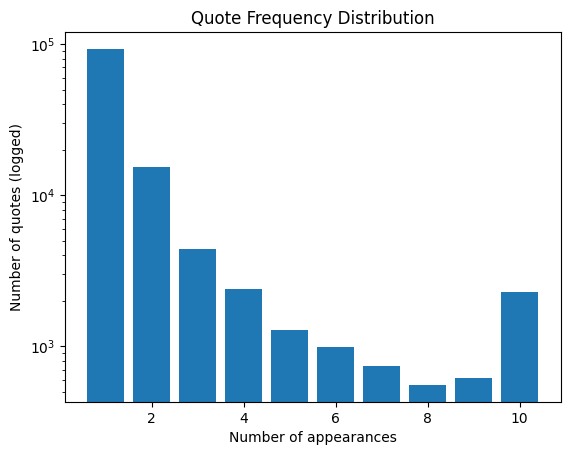

In [ ]:
# plots histogram that shows how many quotes appear...
# 1,2,3,4,5,6,7,8,9, and 10 times

freq_distribution = defaultdict(int)
for count in quote_freq.values():
    if count >= 10:
        freq_distribution[10] += 1
    else:
        freq_distribution[count] += 1

plt.bar(freq_distribution.keys(), freq_distribution.values())
plt.yscale('log')
plt.xlabel("Number of appearances")
plt.ylabel("Number of quotes (logged)")
plt.title("Quote Frequency Distribution")
plt.show()

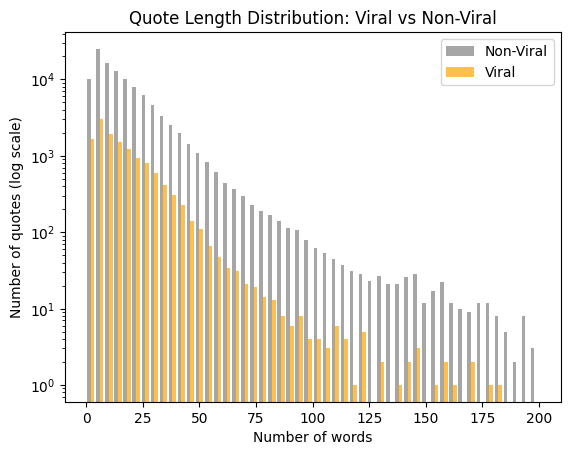

In [ ]:
# plots histogram that shows how many quotes have...
# different certain lengths
# and compares these trends between viral and non-viral quotes

viral_lengths = [len(q.split()) for q, label in labels.items() if label == 1]
nonviral_lengths = [len(q.split()) for q, label in labels.items() if label == 0]

plt.hist(
    [nonviral_lengths, viral_lengths],
    bins=50,
    range=(0, 200),
    color=['gray', 'orange'],
    alpha=0.7,
    label=['Non-Viral', 'Viral']
)
plt.yscale('log')
plt.xlabel("Number of words")
plt.ylabel("Number of quotes (log scale)")
plt.title("Quote Length Distribution: Viral vs Non-Viral")
plt.legend()
plt.show()


In [ ]:
# function that calculates a quote's
# type-token ratio (how much word variety is in it
# based on unique word)

def quote_features(quote):
    words = quote.lower().split()
    total_words = len(words)
    unique_words = len(set(words))
    ttr = unique_words / total_words if total_words > 0 else 0
    return [total_words, unique_words, ttr]

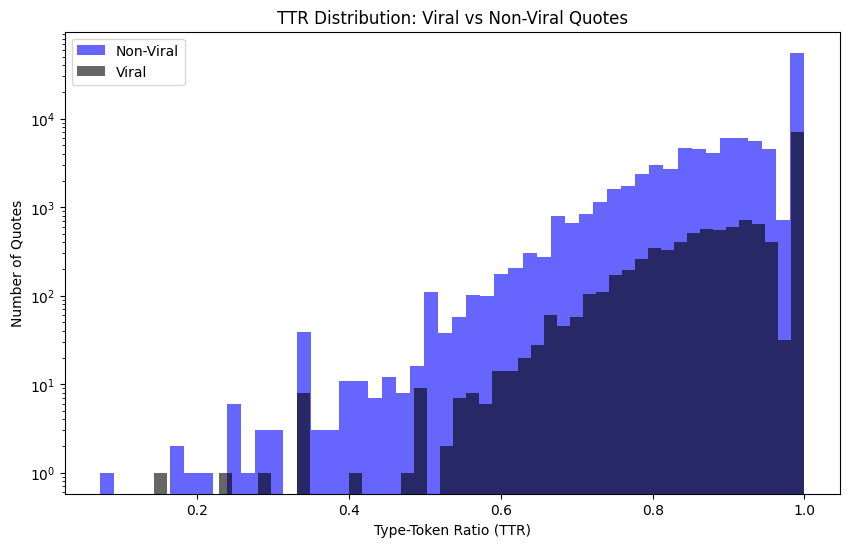

In [ ]:
# plots histogram that shows how many quotes have...
# different type-token ratios
# and compares these trends between viral and non-viral quotes

viral_quotes = [q for q in quote_freq.keys() if labels.get(q, 0) == 1]
nonviral_quotes = [q for q in quote_freq.keys() if labels.get(q, 0) == 0]

viral_ttr = [quote_features(q)[2] for q in viral_quotes]
nonviral_ttr = [quote_features(q)[2] for q in nonviral_quotes]

plt.figure(figsize=(10,6))
plt.hist(nonviral_ttr, bins=50, alpha=0.6, label='Non-Viral', color='blue')
plt.hist(viral_ttr, bins=50, alpha=0.6, label='Viral', color='black')
plt.yscale('log')
plt.xlabel("Type-Token Ratio (TTR)")
plt.ylabel("Number of Quotes")
plt.title("TTR Distribution: Viral vs Non-Viral Quotes")
plt.legend()
plt.show()

In [ ]:
# Part 3: Modeling

In [ ]:
quotes_list = list(quote_freq.keys())
labels_list = [labels[q] for q in quotes_list]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(quotes_list, labels_list, test_size=0.2, random_state=42)

In [ ]:
print(X_train_raw[:10])

["i'm just so sad we had to be here at all we felt this was the last act of parenting for our daughter", 'leave him alone', 'but i grew up near the railroad tracks and industry', "y'all know it's stupid-star calls too", 'fda panel supports avastin for brain cancer', 'we have shown some animated films to children at events and they were interested and had a lot of fun and instructors will be creating projects related to the films that they watched', 'we are proud of the work accomplished by our palmarejo team including the local workforce who completed construction on schedule and on budget combined with production from our other new silver mine san bartolom in bolivia coeur expects silver production to increase 66 this year to approximately 20 million ounces', 'at the last minute', "i got the we're working on it answer", 'mama alam mo doble tingin ko seo pero doble din ganda mo']


In [ ]:
punctuation = set(string.punctuation)

In [ ]:
def counts(dataset):
    wordCount = defaultdict(int)
    bigramCount = defaultdict(int)
    totalWords = 0

    for d in dataset:
        if isinstance(d, dict) and 'quotes' in d:
            for quote in d['quotes']:
                r = quote.lower()
                r = ''.join([c for c in r if not (c in punctuation)])
                words = r.strip().split()
                bigrams = list(zip(words[:-1], words[1:]))
                for w in words:
                    totalWords += 1
                    wordCount[w] += 1
                for b in bigrams:
                    bigramCount[' '.join(b)] += 1

    sortedUnigrams = sorted(wordCount.items(), key=lambda x: x[1], reverse=True)
    sortedBigrams = sorted(bigramCount.items(), key=lambda x: x[1], reverse=True)

    mostCommonUnigrams = [w for (w, count) in sortedUnigrams[:1000]]
    mostCommonBigrams = [b for (b, count) in sortedBigrams[:1000]]

    combined = sorted(
        list(wordCount.items()) + list(bigramCount.items()),
        key=lambda x: x[1],
        reverse=True
    )

    mostCommonBoth = [w for (w, count) in combined[:1000]]

    return mostCommonUnigrams, mostCommonBigrams, mostCommonBoth

In [ ]:
unigrams_train, bigrams_train, both_train = counts([{'quotes':[q]} for q in X_train_raw])


In [ ]:
print(both[:50])

['the', 'to', 'and', 'a', 'of', 'in', 'that', 'i', 'is', 'we', 'it', 'for', 'you', 'this', 'be', 'have', 'are', 'on', 'with', 'was', 'not', 'its', 'as', 'of the', 'they', 'our', 'will', 'in the', 'but', 'at', 'my', 'he', 'de', 'all', 'do', 'what', 'were', 'from', 'an', 'or', 'no', 'can', 'has', 'so', 'there', 'if', 'by', 'people', 'me', 'their']


In [ ]:
def MSE(predictions, y):
    diffs = [(a-b)**2 for (a,b) in zip(predictions, y)]
    return sum(diffs)/len(diffs)

In [ ]:
# Part 3a: Baseline Bag-of-Words Model

In [ ]:
def feature(quote, wordId, wordSet, which):
    # "which" is one of "unigrams", "bigrams", or "both"
    feat = [0] * len(wordSet)

    # Combine all quotes in this datum into one string
    # t = " ".join(datum['quotes']).lower()


    # Remove punctuation
    # t = ''.join([c for c in t if c not in punctuation])
    t = quote.lower()
    t = ''.join([c for c in t if c not in punctuation])
    words = t.strip().split()

    # Collect tokens based on which type
    tokens = []
    if which in ("unigrams", "both"):
        tokens += words
    if which in ("bigrams", "both"):
        tokens += [words[i] + " " + words[i+1] for i in range(len(words)-1)]

    # Count tokens that are in the wordSet
    for token in tokens:
        if token in wordSet:
            feat[wordId[token]] += 1

    return feat

In [ ]:
def fitModel_bow_train(wList, which, dataset, labels_list):
    wordId = dict(zip(wList, range(len(wList))))
    wordSet = set(wList)

    X = [feature(q, wordId, wordSet, which) for q in X_train_raw]
    y = labels_list


    clf = linear_model.Ridge(1.0, fit_intercept=True)
    clf.fit(X, y)
    theta = clf.coef_

    predictions = clf.predict(X)
    mse = MSE(predictions, y)

    return clf, theta, predictions, mse

In [ ]:
# Part 3c: TF-IDF

In [ ]:
# num of times word occurs in quote
def TF(query, wordSet):
    tf = defaultdict(int)

    # Dictionary of term frequencies for the query, and words in wordset.
    # Convert to lower case and remove punctuation.
    # TFs should be binary (i.e., 1 if the word is present), not counts
    r = query
    r = r.lower()
    #print(type(r))
    # print(query)
    r = ''.join([c for c in r if c not in punctuation])
    words = r.strip().split()

    for w in words:
        if w in wordSet:
            tf[w] = 1

    return tf

In [ ]:
def TFIDF(query, df, dataset, wordSet):
    tf = TF(query, wordSet)
    tfidfQuery = [tf[w] * math.log2(len(dataset) / df[w]) for w in wordSet]
    return tfidfQuery

In [ ]:
def fitModel_tfidf_train(wordSet, dataset, labels_list):
    df = defaultdict(int)
    # Compute document frequencies on training set
    for quote in dataset:
        r = quote.lower()
        r = ''.join([c for c in r if c not in punctuation])
        words = set(r.strip().split())  # unique words per doc
        for w in words:
            if w in wordSet:
                df[w] += 1

    # Compute TF-IDF feature vectors for each quote
    X = [TFIDF(q, df, dataset, wordSet) for q in X_train_raw]
    y = labels_list

    # Fit model
    clf = linear_model.Ridge(1.0, fit_intercept=True)
    clf.fit(X, y)
    theta = clf.coef_

    predictions = clf.predict(X)
    mse = MSE(predictions, y)

    return clf, theta, predictions, mse, df


In [ ]:
# Part 4: Evaluation

In [ ]:
# Part 4a: Baseline Bag-of-Words Model

In [ ]:
# bag-of-words with unigrams
clf_bow, theta_bow, predictions_bow, mse_bow_train = fitModel_bow_train(
    wList=unigrams_train,   # vocabulary
    which="unigrams",           # BoW
    dataset=X_train_raw,  # your dataset
    labels_list=y_train
)

In [ ]:
print(mse_bow_train)

0.09511702329392616


In [ ]:
# test predictions

In [ ]:
u_wordId = dict(zip(unigrams, range(len(unigrams))))
u_wordSet = set(unigrams)

In [ ]:
X_test_u = [feature(q, u_wordId, u_wordSet, "unigrams") for q in X_test_raw]

In [ ]:
bow_predictions_test = clf_bow.predict(X_test_u)

In [ ]:
mse_bow_test = MSE(bow_predictions_test, y_test)

In [ ]:
print(mse_bow_test)

0.09999981034432952


In [ ]:
# Part 4b: Bigrams Model

In [ ]:
# Bag-of-words with bigrams
clf_bow_bi, theta_bow_bi, predictions_bow_bi, mse_bow_bi_train = fitModel_bow_train(
    wList=bigrams_train,   # bigram vocabulary
    which="bigrams",       # indicate bigrams
    dataset=X_train_raw,   # your dataset
    labels_list=y_train
)

In [ ]:
print(mse_bow_bi_train)

0.09560198664733388


In [ ]:
# test predictions

In [ ]:
b_wordId = dict(zip(bigrams, range(len(bigrams))))
b_wordSet = set(bigrams)

In [ ]:
X_test_b = [feature(q, b_wordId, b_wordSet, "bigrams") for q in X_test_raw]

In [ ]:
bi_predictions_test = clf_bow_bi.predict(X_test_b)

In [ ]:
mse_bi_test = MSE(bi_predictions_test, y_test)

In [ ]:
print(mse_bi_test)

0.09965742451653443


In [ ]:
# Part 4c: TF-IDF

In [ ]:
clf_tfidf, theta_tfidf, predictions_tfidf, mse_tfidf, df_train = fitModel_tfidf_train(
    wordSet=unigrams_train,
    dataset=X_train_raw,
    labels_list=y_train
)

In [ ]:
print(mse_tfidf)

0.0949319148450313


In [ ]:
# test predictions

In [ ]:
tfidf_predictions_test = clf_tfidf.predict(X_test_u)

In [ ]:
mse_tfidf_test = MSE(tfidf_predictions_test, y_test)

In [ ]:
print(mse_tfidf_test)

0.09860928256725066


In [ ]:
# results table
results = {
    "Model": ["Bag-of-Words (Unigrams)", "Bag-of-Words (Bigrams)", "TF-IDF (Unigrams)"],
    "MSE": [0.0950, 0.0954, 0.0948]
}

# Convert to DataFrame
df = pandas.DataFrame(results)

print(df)

                     Model     MSE
0  Bag-of-Words (Unigrams)  0.0950
1   Bag-of-Words (Bigrams)  0.0954
2        TF-IDF (Unigrams)  0.0948


In [ ]:
!pwd
!ls


/content
drive			 quotes_2009-04.txt.gz.2  quotes_2009-04.txt.gz.5
quotes_2009-04.txt.gz	 quotes_2009-04.txt.gz.3  sample_data
quotes_2009-04.txt.gz.1  quotes_2009-04.txt.gz.4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!jupyter nbconvert --to html /Users/nicole/Downloads/notebook.ipynb


[NbConvertApp] WARNING | pattern '/Users/nicole/Downloads/notebook.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_ye